## MENTAL HEALTH ANALYSIS
**GROUP MEMEBERS : FATIMA MBODJI, ARMIN AHMADKHANIHA, SIRAJ KHAN, VASHAWN ROBINSON**

# PART I : DATA CURATION 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

In [2]:
# Load Murarka et al. (2021) dataset - combine train, val, test splits
murarka_train = pd.read_csv("datasets/raw/both_train.csv")
murarka_val = pd.read_csv("datasets/raw/both_val.csv")
murarka_test = pd.read_csv("datasets/raw/both_test.csv")


# Combine all Murarka splits
murarka_df = pd.concat([murarka_train, murarka_val, murarka_test], ignore_index=True)
murarka_df.head()

,ID,title,post,class_name,class_id
0,691324c4-5c30-44e0-b9e4-45b4f0715e21,a question about the third conditional.,i was making questions for my students and i ran into a little tricky grammar. which is correct ...,none,5
1,d4295391-9ca5-4398-b7c8-687e4a984ef1,the epitome of my life,i've recently requested testing accommodations at my university and was given letters to persona...,adhd,0
2,58937fa5-3c2c-426b-8255-5a140fbab675,what are your favourites offbeat destinations of asia? this is my list.,**cambodia** * koh rong: amazing beaches and a very serene romantic island * kratie: very beauti...,none,5
3,7daf364c-3b33-4cbe-be37-a214edf9a73e,synesthesia survey (what colour is each month to you?),"synesthesia. what is synesthesia? according to google, ""synesthesia is a condition in which one ...",none,5
4,22518271-4bb4-4caf-b683-7305da519288,"science ama series: i’m phil baran, and i’m here to talk about our work at the baran laboratory ...",i’m phil baran and i teach organic chemistry at the scripps research institute. i also head the ...,none,5


In [3]:
print("=== Murarka Label Analysis ===")
print(f"\nUnique class_name values:\n{murarka_df['class_name'].value_counts()}")
print(f"\nUnique class_id values:\n{murarka_df['class_id'].value_counts().sort_index()}")

print(f"\nNull values:\n{murarka_df.isnull().sum()}")

=== Murarka Label Analysis ===

Unique class_name values:
class_name
adhd          2961
depression    2946
anxiety       2918
bipolar       2903
ptsd          2497
none          2478
Name: count, dtype: int64

Unique class_id values:
class_id
0    2961
1    2918
2    2903
3    2946
4    2497
5    2478
Name: count, dtype: int64

Null values:
ID            0
title         0
post          0
class_name    0
class_id      0
dtype: int64


In [4]:
sarkar_df = pd.read_csv("datasets/raw/Combined Data.csv", index_col=0)

print("=== Sarkar Dataset ===")
print(f"Shape: {sarkar_df.shape}")
print(f"\nColumns: {list(sarkar_df.columns)}")
print(f"\nFirst few rows:")
sarkar_df.head()

=== Sarkar Dataset ===
Shape: (53043, 2)

Columns: ['statement', 'status']

First few rows:


,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless heart. All out of tune",Anxiety
2,"All wrong, back off dear, forward doubt. Stay in a restless and restless place",Anxiety
3,I've shifted my focus to something else but I'm still worried,Anxiety
4,"I'm restless and restless, it's been a month now, boy. What do you mean?",Anxiety


In [5]:
SHARED_LABELS = ['Depression', 'Anxiety', 'Bipolar', 'ADHD', 'PTSD', 'None']

def map_murarka_label(label):
    label_map = {
        'adhd': 'ADHD',
        'anxiety': 'Anxiety',
        'bipolar': 'Bipolar',
        'depression': 'Depression',
        'none': 'None',
        'ptsd': 'PTSD'
    }
    return label_map.get(label.lower(), label)

def map_sarkar_label(label):
    label_map = {
        'Depression': 'Depression',
        'Anxiety': 'Anxiety',
        'Bipolar': 'Bipolar',
        'ADHD': 'ADHD',
        'PTSD': 'PTSD',
        'Normal': 'None',
        'Personality disorder': 'None',  
        'Stress': 'None',  
        'Suicidal': 'Depression'  
    }
    return label_map.get(label, label)


In [6]:
murarka_df['text'] = murarka_df['title'].fillna('') + ' ' + murarka_df['post'].fillna('')
murarka_df['text'] = murarka_df['text'].str.strip()

murarka_df['label'] = murarka_df['class_name'].apply(map_murarka_label)
murarka_df['source'] = 'Murarka'

murarka_clean = murarka_df[['text', 'label', 'source']].copy()

murarka_clean.head()

,text,label,source
0,a question about the third conditional. i was making questions for my students and i ran into a ...,None,Murarka
1,the epitome of my life i've recently requested testing accommodations at my university and was g...,ADHD,Murarka
2,what are your favourites offbeat destinations of asia? this is my list. **cambodia** * koh rong:...,None,Murarka
3,synesthesia survey (what colour is each month to you?) synesthesia. what is synesthesia? accordi...,None,Murarka
4,"science ama series: i’m phil baran, and i’m here to talk about our work at the baran laboratory ...",None,Murarka


In [7]:
murarka_df['text'] = murarka_df['title'].fillna('') + ' ' + murarka_df['post'].fillna('')
murarka_df['text'] = murarka_df['text'].str.strip()

murarka_df['label'] = murarka_df['class_name'].apply(map_murarka_label)
murarka_df['source'] = 'Murarka'

murarka_clean = murarka_df[['text', 'label', 'source']].copy()

murarka_clean.head()

,text,label,source
0,a question about the third conditional. i was making questions for my students and i ran into a ...,None,Murarka
1,the epitome of my life i've recently requested testing accommodations at my university and was g...,ADHD,Murarka
2,what are your favourites offbeat destinations of asia? this is my list. **cambodia** * koh rong:...,None,Murarka
3,synesthesia survey (what colour is each month to you?) synesthesia. what is synesthesia? accordi...,None,Murarka
4,"science ama series: i’m phil baran, and i’m here to talk about our work at the baran laboratory ...",None,Murarka


In [9]:
sarkar_df['text'] = sarkar_df['statement'].fillna('').str.strip()

sarkar_df['label'] = sarkar_df['status'].apply(map_sarkar_label)

sarkar_df['source'] = 'Sarkar'

sarkar_clean = sarkar_df[['text', 'label', 'source']].copy()

sarkar_clean.head()

,text,label,source
0,oh my gosh,Anxiety,Sarkar
1,"trouble sleeping, confused mind, restless heart. All out of tune",Anxiety,Sarkar
2,"All wrong, back off dear, forward doubt. Stay in a restless and restless place",Anxiety,Sarkar
3,I've shifted my focus to something else but I'm still worried,Anxiety,Sarkar
4,"I'm restless and restless, it's been a month now, boy. What do you mean?",Anxiety,Sarkar


In [10]:
combined_df = pd.concat([murarka_clean, sarkar_clean], ignore_index=True)

combined_df = combined_df.dropna(subset=['text', 'label'])

combined_df = combined_df[combined_df['text'].str.strip() != '']

combined_df

,text,label,source
0,a question about the third conditional. i was making questions for my students and i ran into a ...,None,Murarka
1,the epitome of my life i've recently requested testing accommodations at my university and was g...,ADHD,Murarka
2,what are your favourites offbeat destinations of asia? this is my list. **cambodia** * koh rong:...,None,Murarka
3,synesthesia survey (what colour is each month to you?) synesthesia. what is synesthesia? accordi...,None,Murarka
4,"science ama series: i’m phil baran, and i’m here to talk about our work at the baran laboratory ...",None,Murarka
...,...,...,...
69741,Nobody takes me seriously I’ve (24M) dealt with depression/anxiety for years now. I used to be g...,Anxiety,Sarkar
69742,"selfishness ""I don't feel very good, it's like I don't belong in this world (I don't think I ev...",Anxiety,Sarkar
69743,"Is there any way to sleep better? I can't sleep most of the nights, meds didn't help.",Anxiety,Sarkar
69744,"Public speaking tips? Hi, all. I have to give a presentation at work next week (45 minutes long ...",Anxiety,Sarkar


In [11]:
duplicates = combined_df['text'].duplicated().sum()

combined_df = combined_df.drop_duplicates(subset=['text'], keep='first')
print(f"Removed {duplicates} duplicate texts")

Removed 1614 duplicate texts


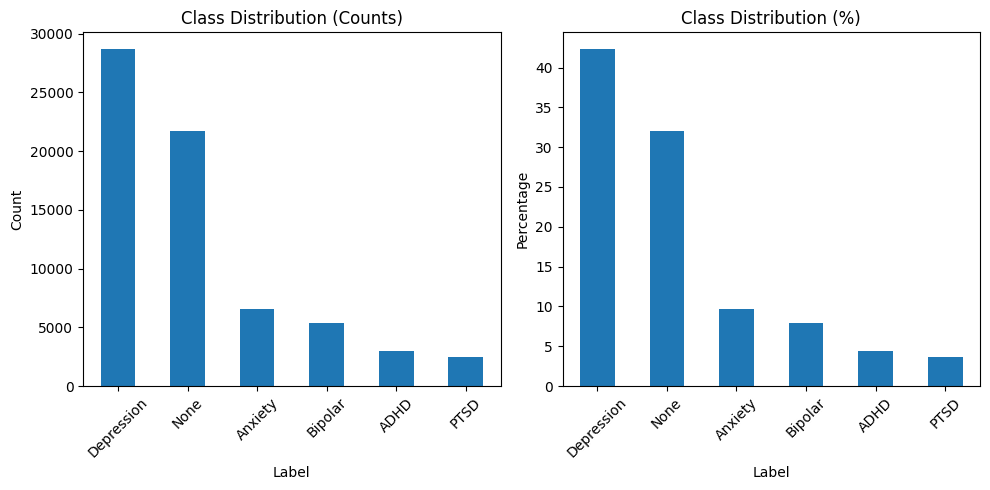

In [12]:
label_counts = combined_df['label'].value_counts()

label_pct = combined_df['label'].value_counts(normalize=True) * 100

max_count = label_counts.max()
class_weights = {label: max_count / count for label, count in label_counts.items()}

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
label_counts.plot(kind='bar')
plt.title('Class Distribution (Counts)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
label_pct.plot(kind='bar')
plt.title('Class Distribution (%)')
plt.xlabel('Label')
plt.ylabel('Percentage')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
combined_df['word_count'] = combined_df['text'].apply(lambda x: len(str(x).split()))

short_posts = combined_df[combined_df['word_count'] < 5]

p99 = combined_df['word_count'].quantile(0.99)
long_posts = combined_df[combined_df['word_count'] > p99]

In [14]:
combined_df = combined_df[combined_df['word_count'] >= 5]

combined_df = combined_df.drop(columns=['word_count'])

In [15]:
output_path = "datasets/processed/mental_health_cleaned.csv"
combined_df.to_csv(output_path, index=False)

combined_df.sample(5, random_state=42)

,text,label,source
56353,i ve had this thought for several year now and i can t break out of my thought i hope you guy wo...,Depression,Sarkar
37234,My life is going nowhere. I lost half the money I had been saving up over the past year from my ...,Depression,Sarkar
6203,megathread: president trump pardons former sheriff joe arpaio president trump pardoned former ar...,None,Murarka
20974,But it's good that the A&W Ipoh Parade is open.,None,Sarkar
44630,"She still invites me to things and hasn't started dating anyone else (or even talked about it), ...",None,Sarkar


Since the data is now cleaned is time for second part which is enginnering rtext features for next part

**Following part is done by seprate member, naming done localy**

## PART II: DATA ENGINEERING

## Feature Enginnering

**Adding Libraries we want use**


In [19]:
import pandas as pd
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import string
import re
import emoji # for counting emojis in each post
cleaned_df=pd.read_csv('datasets/processed/mental_health_cleaned.csv')
cleaned_df


,text,label,source
0,a question about the third conditional. i was making questions for my students and i ran into a ...,NaN,Murarka
1,the epitome of my life i've recently requested testing accommodations at my university and was g...,ADHD,Murarka
2,what are your favourites offbeat destinations of asia? this is my list. **cambodia** * koh rong:...,NaN,Murarka
3,synesthesia survey (what colour is each month to you?) synesthesia. what is synesthesia? accordi...,NaN,Murarka
4,"science ama series: i’m phil baran, and i’m here to talk about our work at the baran laboratory ...",NaN,Murarka
...,...,...,...
64979,Anxiety cause faintness when standing up ? As title does anxiety cause faintness when standing ?...,Anxiety,Sarkar
64980,anxiety heart symptom does anyone else have this or something similar? what do u do to help it? ...,Anxiety,Sarkar
64981,"Travel Anxiety Hi all! Long time anxiety sufferer, first time poster. I am diagnosed bipolar wit...",Anxiety,Sarkar
64982,"fomo from things i’m not involved in does anyone else get this? recently i watched a tv show, an...",Anxiety,Sarkar


**Calculating Post Length AND char Count**
then add it as col to the data frame 

In [20]:
cleaned_df['Post_length'] = cleaned_df['text'].apply(lambda x: len(str(x).split()))
cleaned_df['Char_count'] = cleaned_df['text'].str.len()
cleaned_df

,text,label,source,Post_length,Char_count
0,a question about the third conditional. i was making questions for my students and i ran into a ...,NaN,Murarka,79,457
1,the epitome of my life i've recently requested testing accommodations at my university and was g...,ADHD,Murarka,143,735
2,what are your favourites offbeat destinations of asia? this is my list. **cambodia** * koh rong:...,NaN,Murarka,460,3085
3,synesthesia survey (what colour is each month to you?) synesthesia. what is synesthesia? accordi...,NaN,Murarka,195,1164
4,"science ama series: i’m phil baran, and i’m here to talk about our work at the baran laboratory ...",NaN,Murarka,338,2048
...,...,...,...,...,...
64979,Anxiety cause faintness when standing up ? As title does anxiety cause faintness when standing ?...,Anxiety,Sarkar,23,130
64980,anxiety heart symptom does anyone else have this or something similar? what do u do to help it? ...,Anxiety,Sarkar,61,306
64981,"Travel Anxiety Hi all! Long time anxiety sufferer, first time poster. I am diagnosed bipolar wit...",Anxiety,Sarkar,159,851
64982,"fomo from things i’m not involved in does anyone else get this? recently i watched a tv show, an...",Anxiety,Sarkar,172,891


## Calculation Density of Punctuations and Emojis
there are amount of emojisa and punctuations existed in each post which can highlight a chance of underlying **MENTAL HEALTH ISSUE**

In [21]:
cleaned_df['Count_?'] = cleaned_df['text'].str.count(re.escape('?')).fillna(0).astype(int)# if posts are free of any punctuations return 0
cleaned_df['Count_!'] = cleaned_df['text'].str.count(re.escape('!')).fillna(0).astype(int)
##counting emojis in each post 
cleaned_df['Count_emoji'] = cleaned_df['text'].apply(lambda x: 0 if pd.isna(x) else emoji.emoji_count(str(x)))
cleaned_df

,text,label,source,Post_length,Char_count,Count_?,Count_!,Count_emoji
0,a question about the third conditional. i was making questions for my students and i ran into a ...,NaN,Murarka,79,457,2,0,0
1,the epitome of my life i've recently requested testing accommodations at my university and was g...,ADHD,Murarka,143,735,0,0,0
2,what are your favourites offbeat destinations of asia? this is my list. **cambodia** * koh rong:...,NaN,Murarka,460,3085,1,0,0
3,synesthesia survey (what colour is each month to you?) synesthesia. what is synesthesia? accordi...,NaN,Murarka,195,1164,2,1,0
4,"science ama series: i’m phil baran, and i’m here to talk about our work at the baran laboratory ...",NaN,Murarka,338,2048,0,2,0
...,...,...,...,...,...,...,...,...
64979,Anxiety cause faintness when standing up ? As title does anxiety cause faintness when standing ?...,Anxiety,Sarkar,23,130,3,0,0
64980,anxiety heart symptom does anyone else have this or something similar? what do u do to help it? ...,Anxiety,Sarkar,61,306,4,0,0
64981,"Travel Anxiety Hi all! Long time anxiety sufferer, first time poster. I am diagnosed bipolar wit...",Anxiety,Sarkar,159,851,2,1,0
64982,"fomo from things i’m not involved in does anyone else get this? recently i watched a tv show, an...",Anxiety,Sarkar,172,891,3,0,0


## VADER SCORING
The **VADER LIB** is a great tool that helps us parse the text and findout about compund score. this score is between -1 to 1 which closer to negative side means the text imperssion is negaitve while as it get closer to positive side it shows more satisfaction we can use this score in trainning our model 

In [23]:
analyzer = SentimentIntensityAnalyzer() ##intiliazing Analyzer 
cleaned_df['Vader_variable'] = cleaned_df['text'].apply(lambda x: analyzer.polarity_scores(x)['compound']) ## add the col to the data frame
cleaned_df

,text,label,source,Post_length,Char_count,Count_?,Count_!,Count_emoji,Vader_variable
0,a question about the third conditional. i was making questions for my students and i ran into a ...,NaN,Murarka,79,457,2,0,0,0.5799
1,the epitome of my life i've recently requested testing accommodations at my university and was g...,ADHD,Murarka,143,735,0,0,0,0.3875
2,what are your favourites offbeat destinations of asia? this is my list. **cambodia** * koh rong:...,NaN,Murarka,460,3085,1,0,0,0.9997
3,synesthesia survey (what colour is each month to you?) synesthesia. what is synesthesia? accordi...,NaN,Murarka,195,1164,2,1,0,0.8904
4,"science ama series: i’m phil baran, and i’m here to talk about our work at the baran laboratory ...",NaN,Murarka,338,2048,0,2,0,0.9922
...,...,...,...,...,...,...,...,...,...
64979,Anxiety cause faintness when standing up ? As title does anxiety cause faintness when standing ?...,Anxiety,Sarkar,23,130,3,0,0,-0.4479
64980,anxiety heart symptom does anyone else have this or something similar? what do u do to help it? ...,Anxiety,Sarkar,61,306,4,0,0,0.9190
64981,"Travel Anxiety Hi all! Long time anxiety sufferer, first time poster. I am diagnosed bipolar wit...",Anxiety,Sarkar,159,851,2,1,0,-0.9585
64982,"fomo from things i’m not involved in does anyone else get this? recently i watched a tv show, an...",Anxiety,Sarkar,172,891,3,0,0,0.9140


NOW before visualizing and analysis we suppsoe to do text proccessing for better understanding

**Following part is done by seprate member, naming done localy**


## PART III : TEXT_PROCESSING

## Setup

`nltk` needs three data packages the first time you run this: `punkt`/`punkt_tab` (for the tokenizer)
and `stopwords` (for the stopword list). The cell below downloads them if they're missing.

In [31]:
import os
import re
import html
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download required NLTK data. Safe to re-run: if a package is already
# present, nltk.download just confirms it and moves on (no error).
for pkg in ['punkt', 'punkt_tab', 'stopwords']:
    nltk.download(pkg)

pd.set_option('display.max_colwidth', 120)

[nltk_data] Downloading package punkt to /Users/skhan/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /Users/skhan/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /Users/skhan/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



> **Justing writing this here,so why `keep_default_na=False`:** one of our classes is literally named `None`, and by
> default `pandas.read_csv` treats the string `"None"` as a missing value (NaN). A plain
> `pd.read_csv(...)` silently turns the **entire `None` class (~18k+ rows, our second-largest class)**
> into NaN. Disabling default NA conversion keeps the label intact.

In [32]:
# Resolve paths relative to the repo root 

try:
    REPO_ROOT = os.path.dirname(os.path.abspath(__file__))
except NameError:
    REPO_ROOT = os.getcwd()

# If the data folder is not found next to the notebook, also try common fallbacks.
DATA_DIR = os.path.join(REPO_ROOT, 'datasets', 'processed')
if not os.path.isdir(DATA_DIR):
    alt = os.path.expanduser('~/Mental-data-diagnosis-/datasets/processed')
    if os.path.isdir(alt):
        DATA_DIR = alt

INPUT_PATH = os.path.join(DATA_DIR, 'mental_health_cleaned.csv')
print("Reading from:", INPUT_PATH)

# keep_default_na=False so the literal "None" label is NOT read as NaN
df = pd.read_csv(INPUT_PATH, keep_default_na=False, na_values=[])

print(f"Loaded {len(df):,} rows")
print("Columns:", list(df.columns))
df.head()

Reading from: /Users/skhan/Documents/epoch-dev/Mental-data-diagnosis-/datasets/processed/mental_health_cleaned.csv
Loaded 64,984 rows
Columns: ['text', 'label', 'source']


,text,label,source
0,a question about the third conditional. i was making questions for my students and i ran into a little tricky gramma...,None,Murarka
1,the epitome of my life i've recently requested testing accommodations at my university and was given letters to pers...,ADHD,Murarka
2,what are your favourites offbeat destinations of asia? this is my list. **cambodia** * koh rong: amazing beaches and...,None,Murarka
3,"synesthesia survey (what colour is each month to you?) synesthesia. what is synesthesia? according to google, ""synes...",None,Murarka
4,"science ama series: i’m phil baran, and i’m here to talk about our work at the baran laboratory where we try to simp...",None,Murarka


In [33]:
# Visibility check on labels (should be the 6 shared classes)
print(df['label'].value_counts())

label
Depression    28565
None          19109
Anxiety        6453
Bipolar        5401
ADHD           2961
PTSD           2495
Name: count, dtype: int64


In [34]:
# --- Step 7 resource: English stopwords ---
STOPWORDS = set(stopwords.words('english'))

# --- Compiled patterns ---
URL_RE      = re.compile(r'http\S+|www\.\S+')          # step 3
HTML_TAG_RE = re.compile(r'<[^>]+>')                      # step 4
REDDIT_RE   = re.compile(r'\[removed\]|\[deleted\]', re.IGNORECASE)  # step 4
PUNCT_RE    = re.compile(r"[^a-z0-9'\s]")                # step 5: keep letters, digits, apostrophes, spaces

def preprocess_text(text):
    text = str(text)

    # 2. lowercase
    text = text.lower()

    # 3. remove URLs
    text = URL_RE.sub(' ', text)

    # 4. remove HTML tags + decode HTML entities (&amp;, &#x200b;, ...) + Reddit markup
    text = html.unescape(text)
    text = HTML_TAG_RE.sub(' ', text)
    text = REDDIT_RE.sub(' ', text)

    # 5. remove punctuation / special chars, but KEEP apostrophes for contractions
    text = text.replace('\u2019', "'").replace('\u02bc', "'")  # normalize curly apostrophes
    text = PUNCT_RE.sub(' ', text)

    # 6. tokenize
    tokens = word_tokenize(text)

    # 7. stopword removal (also drop the clitic/punctuation fragments word_tokenize
    #    produces from contractions, e.g. "n't", "'ve", by keeping alphabetic tokens only)
    tokens = [t for t in tokens if t.isalpha() and t not in STOPWORDS]

    return tokens

In [35]:
for i in range(3):
    raw = df['text'].iloc[i]
    print("RAW  :", raw[:140])
    print("CLEAN:", " ".join(preprocess_text(raw))[:140])
    print("-" * 80)

RAW  : a question about the third conditional. i was making questions for my students and i ran into a little tricky grammar. which is correct (foc
CLEAN: question third conditional making questions students ran little tricky grammar correct focusing latter part sentence traveled australia yest
--------------------------------------------------------------------------------
RAW  : the epitome of my life i've recently requested testing accommodations at my university and was given letters to personally give to my profes
CLEAN: epitome life recently requested testing accommodations university given letters personally give professors gave first one saw nice next day 
--------------------------------------------------------------------------------
RAW  : what are your favourites offbeat destinations of asia? this is my list. **cambodia** * koh rong: amazing beaches and a very serene romantic 
CLEAN: favourites offbeat destinations asia list cambodia koh rong amazing beaches serene romantic

In [36]:
df['tokens'] = df['text'].apply(preprocess_text)
df['clean_text'] = df['tokens'].apply(lambda toks: ' '.join(toks))

# Sanity checks
token_counts = df['tokens'].apply(len)
print(f"Rows processed         : {len(df):,}")
print(f"Avg tokens per post    : {token_counts.mean():.1f}")
print(f"Posts empty after clean: {(token_counts == 0).sum()}  (consider dropping before modeling)")
df[["text", "label", "clean_text"]].head()

Rows processed         : 64,984
Avg tokens per post    : 64.8
Posts empty after clean: 28  (consider dropping before modeling)


,text,label,clean_text
0,a question about the third conditional. i was making questions for my students and i ran into a little tricky gramma...,None,question third conditional making questions students ran little tricky grammar correct focusing latter part sentence...
1,the epitome of my life i've recently requested testing accommodations at my university and was given letters to pers...,ADHD,epitome life recently requested testing accommodations university given letters personally give professors gave firs...
2,what are your favourites offbeat destinations of asia? this is my list. **cambodia** * koh rong: amazing beaches and...,None,favourites offbeat destinations asia list cambodia koh rong amazing beaches serene romantic island kratie beautiful ...
3,"synesthesia survey (what colour is each month to you?) synesthesia. what is synesthesia? according to google, ""synes...",None,synesthesia survey colour month synesthesia synesthesia according google synesthesia condition one sense example hea...
4,"science ama series: i’m phil baran, and i’m here to talk about our work at the baran laboratory where we try to simp...",None,science ama series phil baran talk work baran laboratory try simplify way molecules created also macarthur fellow ge...


At last we visualize our cleaned and processed data for final conclusion

**Following part is done by more than one member, all the namings done localy**


## PART IV: DATA VISUALIZATION & SUMMARY

## Analysis of Word distrbution 

We are looking to see if there are any direct connection between length of each person text and the **Mental Health Issue**  they are suffering

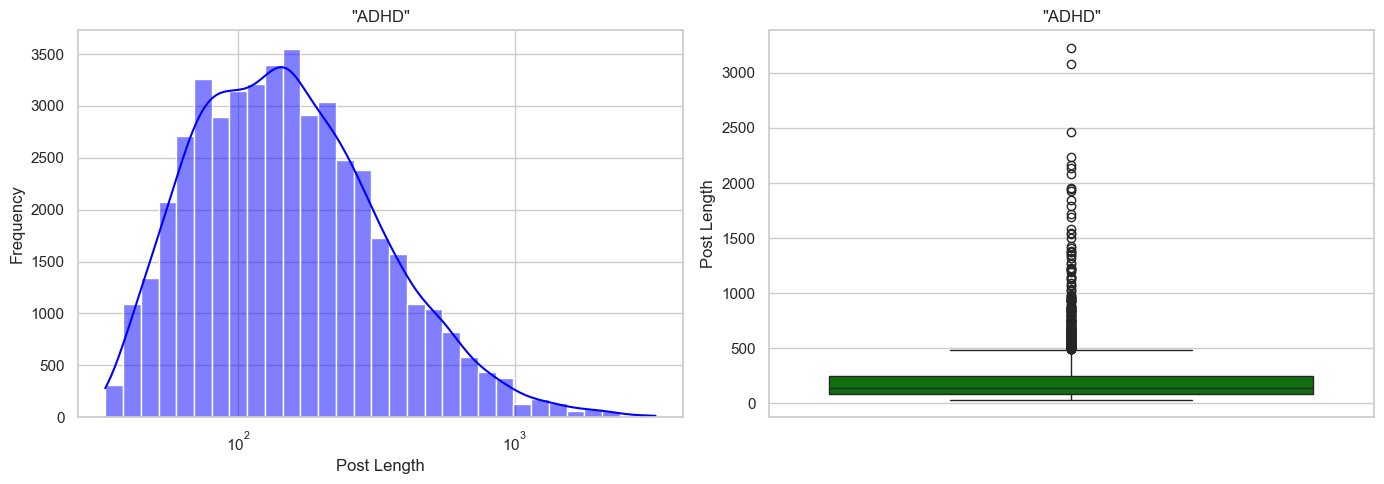

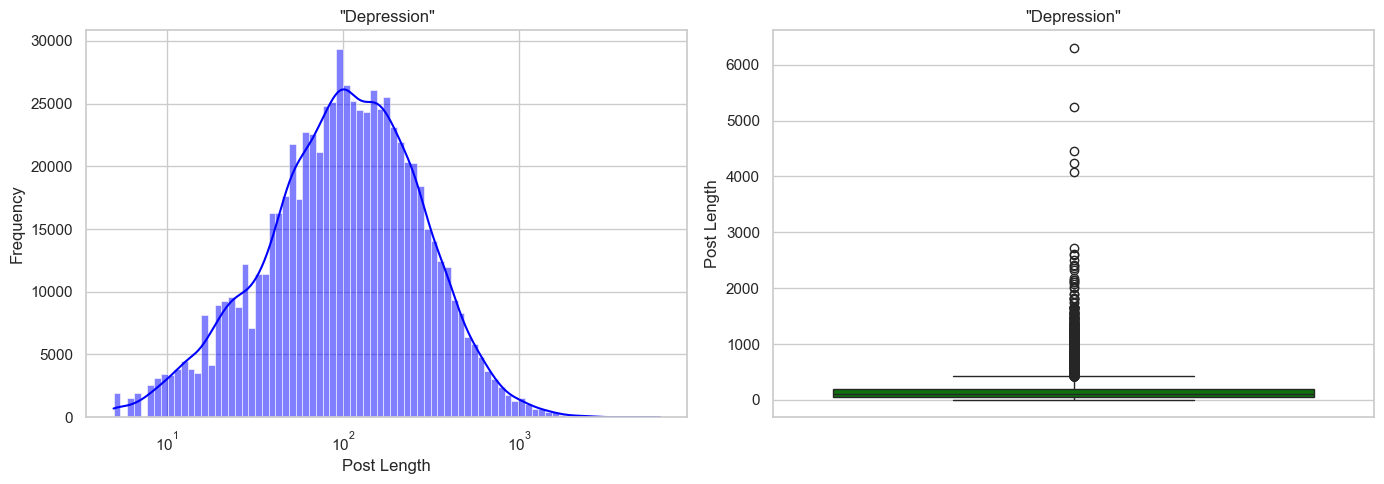

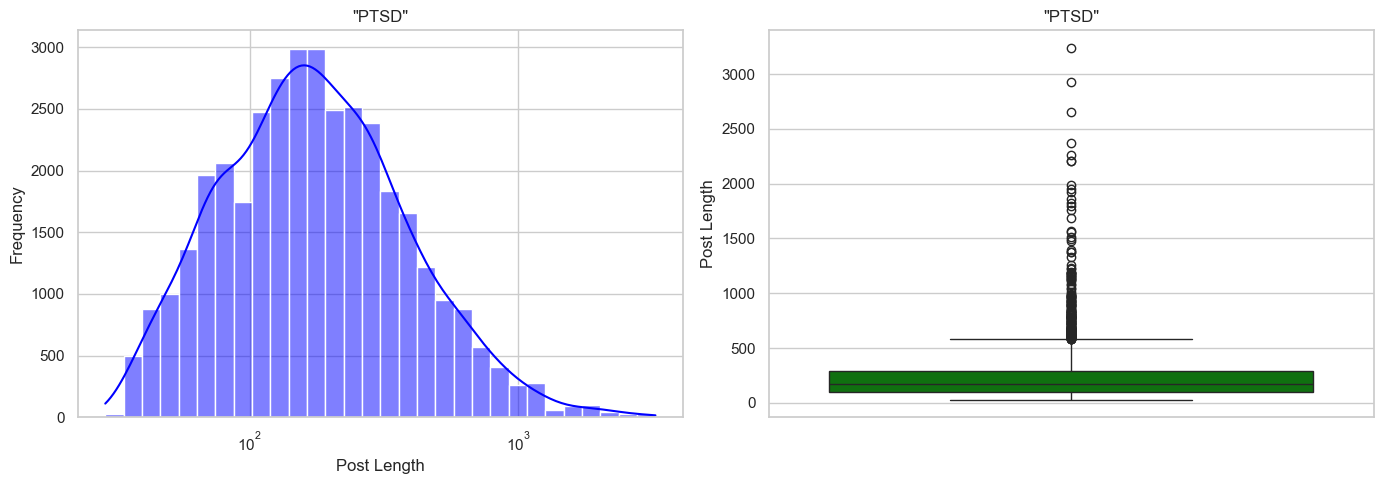

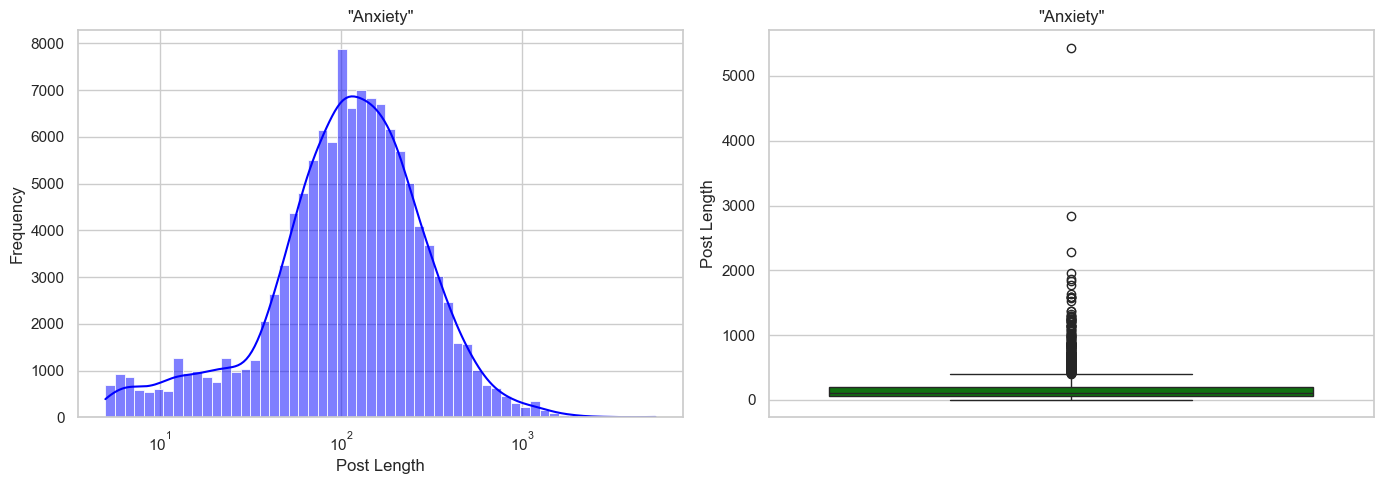

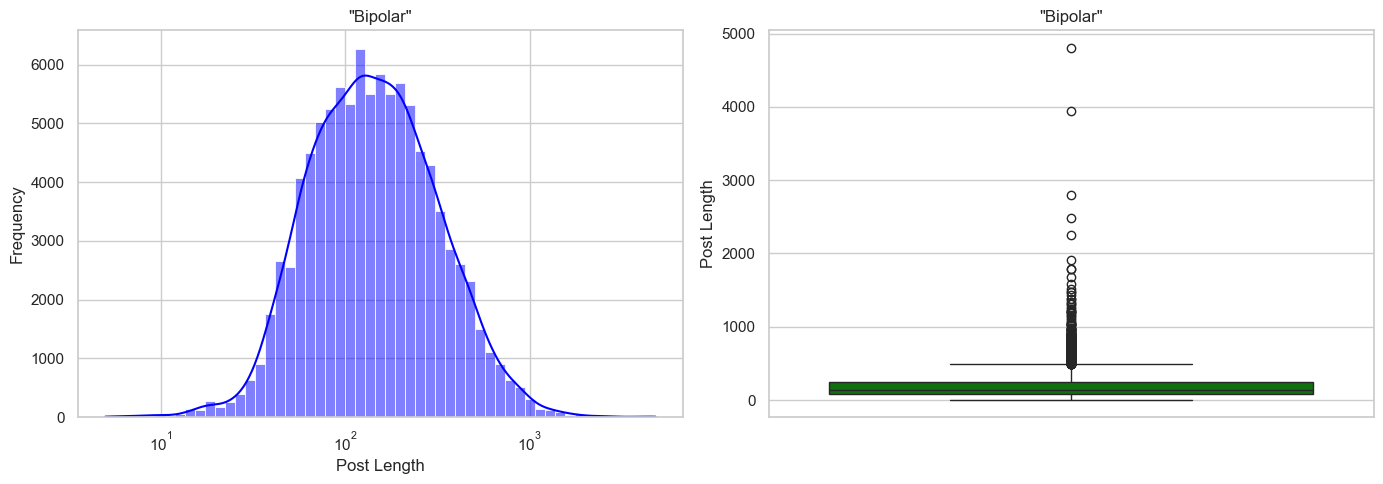

In [38]:
import matplotlib.pyplot as plt
import seaborn as sb

sb.set_theme(style="whitegrid")

visual_df = cleaned_df.dropna(subset=['label', 'Post_length']).copy()
unique_labels = visual_df['label'].unique()

for label in unique_labels:
    subset_df = visual_df[visual_df['label'] == label]  
    fig, axes = plt.subplots(1, 2, figsize=(14, 5)) 
    
    # Histogram
    sb.histplot(
        data=subset_df, 
        x='Post_length', 
        kde=True, 
        ax=axes[0], 
        color='blue',
        stat='frequency', #  we want to plot based on numbers we have
        log_scale=True # to also show frequency on X axis
    )    
    axes[0].set_title(f'"{label}"')
    axes[0].set_xlabel('Post Length')
    
    # Boxplot 
    sb.boxplot(data=subset_df, y='Post_length', ax=axes[1], color='Green')
    axes[1].set_title(f'"{label}"')
    axes[1].set_ylabel('Post Length')
    
    plt.tight_layout()
    plt.show()

## Interpertation of the results
As I reviewed the the result I noticed patterns that are connected in some ways to the type of disorder each patient is dealing with:

## ADHD
People with ADHD disorder tend to have short focus so their posts, brief, punchy posts. The absolute longest post in this category is around 3000 words, which is actually one of the shortest maximum lengths among all your categories.
## DEPRESSION
This class is highly varied. You have a huge number of very short posts (people perhaps just dropping a quick, one-sentence thought or title), but you also have the most extreme outliers in your entire dataset. Users here are occasionally writing massive, diary-like entries to vent.
## PTSD
This category posts are slightly longer and more detailed on average than others . They don't quite reach the extreme 6,000-word lengths of the Depression category, but the baseline patient tends to write a bit more context.
## ANXIETY
The core behavior here perfectly mirrors the overall dataset: quick, 100-word thoughts make up the vast majority, but there is a very strong, consistent habit of users writing highly detailed, lengthy explanations of their anxious experiences.
## BIPOLAR
very similar to **ANXIETY** category. There are no massive surprises here; it represents a healthy, expected distribution of internet forum text data.

In [44]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv(
    'datasets/processed/mental_health_cleaned.csv'
)

df['label'] = df['label'].fillna('None')
print(df['label'].value_counts())
print(df.shape)

label
Depression    28565
None          19109
Anxiety        6453
Bipolar        5401
ADHD           2961
PTSD           2495
Name: count, dtype: int64
(64984, 3)


## Test 1 — Mann-Whitney U

Null hypothesis (H₀): Posts from people showing signs of mental illness (Depression) are *not* systematically longer or shorter than posts from people without (None).  
Alternative (H₁): The two groups differ in post length (two-sided).

In [1]:
dep  = cleaned_df[cleaned_df['label'] == 'Depression']['Post_length'].dropna()
none = cleaned_df[cleaned_df['label'] == 'None']['Post_length'].dropna()

stat_mwu, p_mwu = stats.mannwhitneyu(dep, none, alternative='two-sided')

print(f'Depression  n={len(dep):,}  median={dep.median():.1f} words')
print(f'None        n={len(none):,}  median={none.median():.1f} words')
print(f'Mann-Whitney U = {stat_mwu:,.0f}')
print(f'p-value        = {p_mwu:.4e}')
if p_mwu < 0.05:
    print('=> Reject H₀ at α=0.05: post lengths differ significantly.')
else:
    print('=> Fail to reject H₀ at α=0.05.')

NameError: name 'cleaned_df' is not defined

### Conclusion — Mann-Whitney U Test

We reject H₀ (U = 420,165,174, p ≈ 0). Depression posts are systematically and substantially longer than posts with no label.

- Dataset characteristics: The dataset contains 64,984 posts across 7 class labels. The Depression class is the largest labeled group, while the None class serves as a control group for this comparison.
- Feature behavior: Post length is skewed heavily to the right in both groups, with extreme outliers reaching thousands of words. This is consistent with the venting behavior documented in the feature engineering analysis. This is shown in the 99th-percentile cap used in the boxplot.
- Key finding: Depression posts have a median of 105 words vs. only 17 words for None posts, which means posts that show signs of depression tend to be much longer than posts that show no signs. This is not a marginal effect. It reflects a real behavioral pattern where users with symptoms of depression use social media as an outlet for their complicated emotions.
- Outliers: Both groups contain extreme outliers, but Depression's upper tail is far longer. This is to be expected, as they represent users writing extended personal narratives. They should be preserved for modeling.
- Implications: Post length is a strong, statistically validated discriminative feature between mentally ill and non-mentally-ill posts. It will likely carry high importance in any classification model. Since the distribution is not normal and heavily skewed, tree-based models or models with log-transformed features will handle it better than linear ones that assume normality.

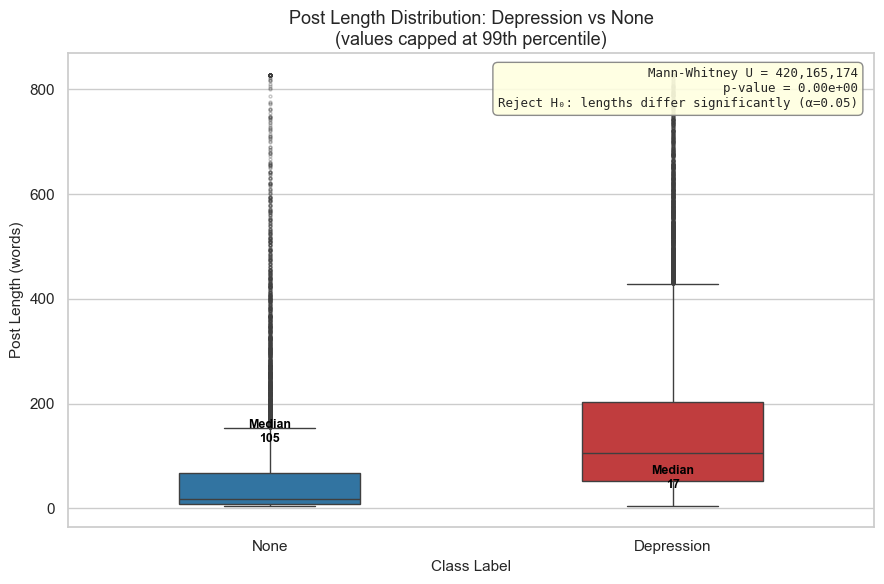

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

plot_data = df[df['label'].isin(['Depression', 'None'])][['label', 'Post_length']].dropna()
plot_data_clipped = plot_data.copy()
cap = plot_data_clipped['Post_length'].quantile(0.99)
plot_data_clipped['Post_length'] = plot_data_clipped['Post_length'].clip(upper=cap)

palette = {'Depression': '#d62728', 'None': '#1f77b4'}
sns.boxplot(
    data=plot_data_clipped,
    x='label', y='Post_length',
    palette=palette,
    width=0.45,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

for i, (grp, color) in enumerate(palette.items()):
    med = plot_data_clipped[plot_data_clipped['label'] == grp]['Post_length'].median()
    ax.text(i, med + cap * 0.02, f'Median\n{med:.0f}', ha='center', va='bottom',
            fontsize=9, color='black', fontweight='bold')

conclusion = (
    f'Mann-Whitney U = {stat_mwu:,.0f}\n'
    f'p-value = {p_mwu:.2e}\n'
    + ('Reject H₀: lengths differ significantly (α=0.05)' if p_mwu < 0.05
       else 'Fail to reject H₀ (α=0.05)')
)
ax.text(0.98, 0.97, conclusion,
        transform=ax.transAxes, va='top', ha='right',
        fontsize=9, family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

ax.set_title('Post Length Distribution: Depression vs None\n(values capped at 99th percentile)', fontsize=13)
ax.set_xlabel('Class Label', fontsize=11)
ax.set_ylabel('Post Length (words)', fontsize=11)
plt.tight_layout()
plt.show()

## Test 2 — Chi-Squared

Null hypothesis (H₀): Whether a post is high- or low-sentiment is unrelated to which mental health class it belongs to.  
Alternative (H₁): Sentiment polarity and class label are associated.

In [ ]:
df_chi = df[df['label'] != 'None'].dropna(subset=['Vader_variable', 'label']).copy()
df_chi['Sentiment'] = df_chi['Vader_variable'].apply(lambda v: 'High' if v >= 0 else 'Low')

contingency = pd.crosstab(df_chi['Sentiment'], df_chi['label'])
print('Contingency table (Sentiment × Class):')
print(contingency)

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print(f'\nChi² = {chi2:.4f}   dof = {dof}   p-value = {p_chi2:.4e}')
if p_chi2 < 0.05:
    print('=> Reject H₀ at α=0.05: sentiment polarity is associated with class.')
else:
    print('=> Fail to reject H₀ at α=0.05.')

Contingency table (Sentiment × Class):
label      ADHD  Anxiety  Bipolar  Depression  PTSD  Personality disorder
Sentiment                                                                
High       1796     2274     2564        8658   806                   430
Low        1165     4179     2837       19907  1689                   465

Chi² = 1567.9764   dof = 5   p-value = 0.0000e+00
=> Reject H₀ at α=0.05: sentiment polarity is associated with class.


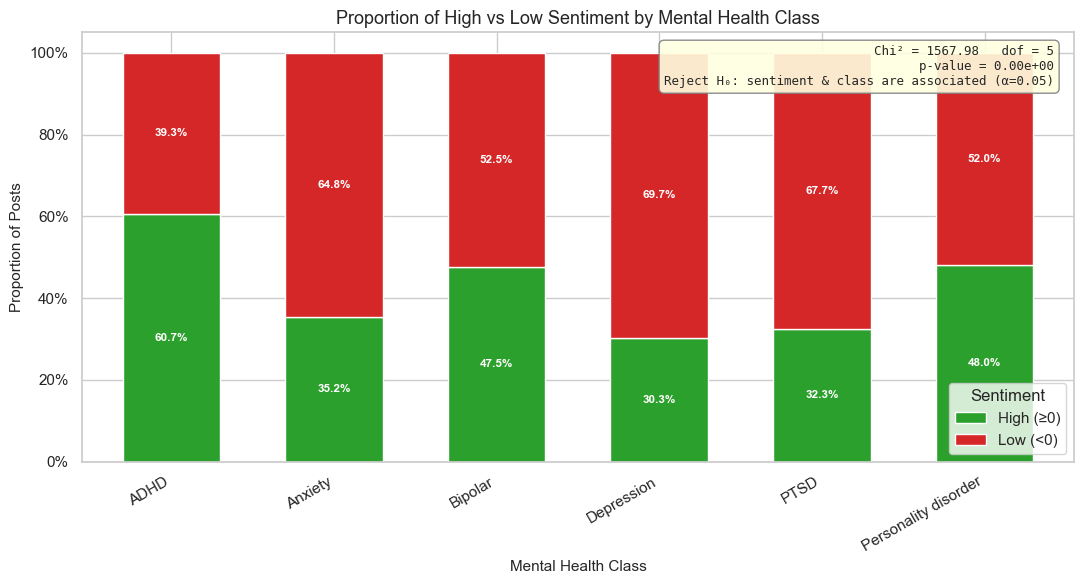

In [ ]:
proportions = contingency.div(contingency.sum(axis=0), axis=1).T
proportions = proportions[['High', 'Low']]

fig, ax = plt.subplots(figsize=(11, 6))

colors = ['#2ca02c', '#d62728']
proportions.plot(kind='bar', stacked=True, color=colors, ax=ax, width=0.6, edgecolor='white')

for container in ax.containers:
    for bar in container:
        h = bar.get_height()
        if h > 0.04:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + h / 2,
                f'{h:.1%}',
                ha='center', va='center', fontsize=8.5, color='white', fontweight='bold'
            )

conclusion = (
    f'Chi² = {chi2:.2f}   dof = {dof}\n'
    f'p-value = {p_chi2:.2e}\n'
    + ('Reject H₀: sentiment & class are associated (α=0.05)' if p_chi2 < 0.05
       else 'Fail to reject H₀ (α=0.05)')
)
ax.text(0.98, 0.97, conclusion,
        transform=ax.transAxes, va='top', ha='right',
        fontsize=9, family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

ax.set_title('Proportion of High vs Low Sentiment by Mental Health Class', fontsize=13)
ax.set_xlabel('Mental Health Class', fontsize=11)
ax.set_ylabel('Proportion of Posts', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(title='Sentiment', labels=['High (≥0)', 'Low (<0)'], loc='lower right')
plt.tight_layout()
plt.show()

### Conclusion — Chi-Squared Test

We reject H₀ (χ² = 1567.98, dof = 5, p ≈ 0). Sentiment polarity (high vs. low) is strongly associated with mental health class. They are not independent.


- Class imbalance: The dataset is heavily imbalanced. Majority of the labeled posts belong to the Depression class, almost 45%. This over-representation means any model trained without resampling or class weighting will be biased toward predicting Depression.
- Key finding: The proportion of low-sentiment posts varies dramatically by class. Depression (70% low) and PTSD (68% low) are the most negatively charged classes, while ADHD (60% high) is the only class where positive-sentiment posts are the majority. Bipolar sits in the middle, reflecting a polarized emotional profile.
- Feature correlation with label: The VADER compound score is not independent of the class label. It is a correlated, informative feature. This confirms that it should be included in the feature set for classification.
- Correlation: The sentiment score and class label are statistically dependent (p ≈ 0), confirming that text sentiment captures real signal about the type of disorder being expressed. However, this also means we must be careful about multicollinearity if using both raw sentiment scores and derived binary sentiment features simultaneously in a linear model.
- Implications: Because sentiment polarity differs so strongly across classes, Vader_variable will be a useful feature. The class imbalance (Depression dominating) should be handled via stratified splits, SMOTE, or weighted loss functions to avoid the model collapsing to always predicting Depression.

## Test 3 — Kruskal-Wallis

Null hypothesis (H₀): Sentiment scores do not systematically differ across the mental health classes (all class distributions are equal).  
Alternative (H₁): At least one class has a systematically different sentiment distribution.

In [ ]:
df_kw = df[df['label'] != 'None'].dropna(subset=['Vader_variable', 'label'])

groups = [grp['Vader_variable'].values for _, grp in df_kw.groupby('label')]
stat_kw, p_kw = stats.kruskal(*groups)

print('Median sentiment score per class:')
print(df_kw.groupby('label')['Vader_variable'].median().round(4).to_string())
print(f'\nKruskal-Wallis H = {stat_kw:.4f}   p-value = {p_kw:.4e}')
if p_kw < 0.05:
    print('=> Reject H₀ at α=0.05: sentiment differs across at least one class.')
else:
    print('=> Fail to reject H₀ at α=0.05.')

Median sentiment score per class:
label
ADHD                    0.5209
Anxiety                -0.5653
Bipolar                -0.2052
Depression             -0.7462
PTSD                   -0.7989
Personality disorder   -0.1531

Kruskal-Wallis H = 1848.7730   p-value = 0.0000e+00
=> Reject H₀ at α=0.05: sentiment differs across at least one class.


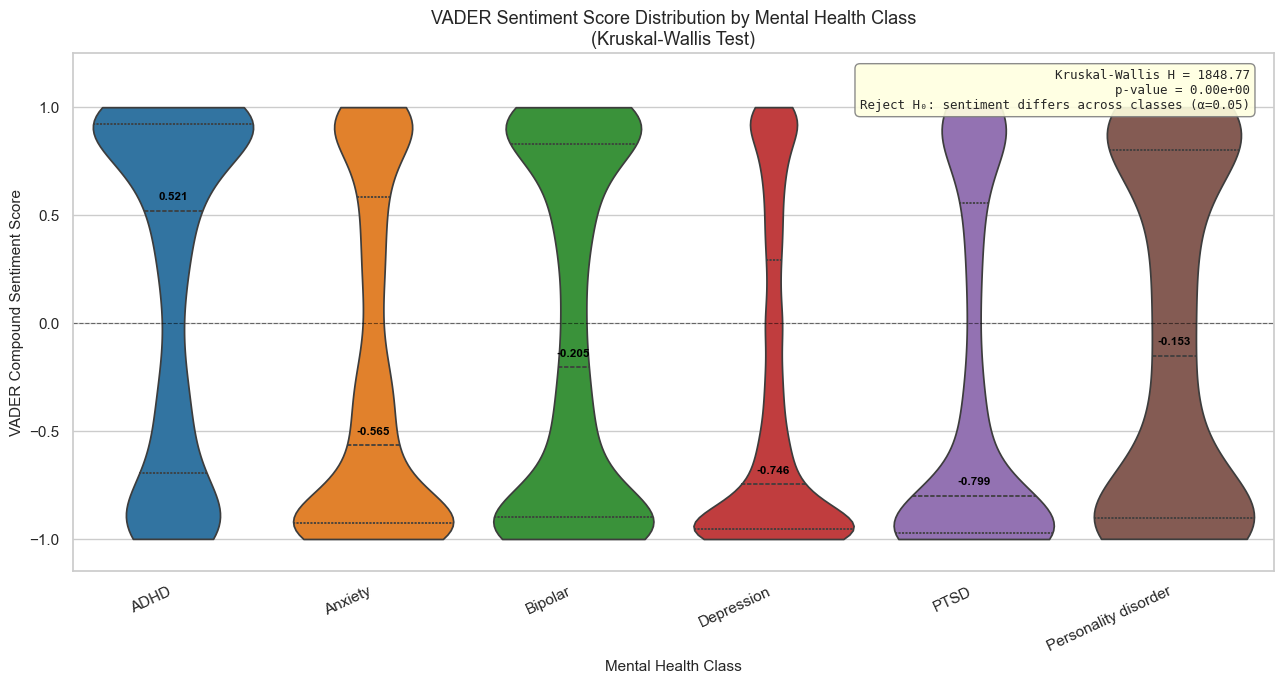

In [ ]:
CLASS_ORDER = sorted(df_kw['label'].unique())
palette = sns.color_palette('tab10', len(CLASS_ORDER))

fig, ax = plt.subplots(figsize=(13, 7))

sns.violinplot(
    data=df_kw,
    x='label', y='Vader_variable',
    order=CLASS_ORDER,
    palette=palette,
    inner='quartile',
    cut=0,
    ax=ax
)

for i, cls in enumerate(CLASS_ORDER):
    med = df_kw[df_kw['label'] == cls]['Vader_variable'].median()
    ax.text(i, med + 0.04, f'{med:.3f}', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color='black')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

conclusion = (
    f'Kruskal-Wallis H = {stat_kw:.2f}\n'
    f'p-value = {p_kw:.2e}\n'
    + ('Reject H₀: sentiment differs across classes (α=0.05)' if p_kw < 0.05
       else 'Fail to reject H₀ (α=0.05)')
)
ax.text(0.98, 0.97, conclusion,
        transform=ax.transAxes, va='top', ha='right',
        fontsize=9, family='monospace',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

ax.set_title('VADER Sentiment Score Distribution by Mental Health Class\n(Kruskal-Wallis Test)', fontsize=13)
ax.set_xlabel('Mental Health Class', fontsize=11)
ax.set_ylabel('VADER Compound Sentiment Score', fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.set_ylim(-1.15, 1.25)
plt.tight_layout()
plt.show()

### Conclusion — Kruskal-Wallis Test

We reject H₀ (H = 1848.77, p ≈ 0). Sentiment scores differ systematically across at least one pair of mental health classes. The distributions are not all equal.

- Key finding: There is a clear and clinically meaningful gradient in median sentiment across classes:
  - ADHD (+0.521) — the only class with a positive median, consistent with energetic, hyperfocused, or celebratory posting behavior.
  - Bipolar (−0.205) — mildly negative median with a wide, bimodal violin shape, reflecting the intense emotional swings characteristic of these conditions.
  - Anxiety (−0.565), Depression (−0.746), and PTSD (−0.799) — the most negatively charged group, where the bulk of posts express distress, fear, or hopelessness.
- The violin plots reveal that this is not just about medians. ADHD has a single dominant positive peak. Depression and PTSD have heavy mass concentrated at very negative scores. Bipolar shows a near-hourglass shape. A single median does not adequately summarize this bimodal shape.
- Outliers: All classes contain posts scoring near ±1.0 (the VADER extremes), but the proportion of extreme-negative posts is far higher in Depression and PTSD.
- Feature correlation: Since "Vader_variable" separates classes so significantly (H = 1848.77), it is statistically validated as a high-value feature for multi-class classification. It is correlated with the label in a way that is both statistically and clinically interpretable.
- Implications: The bimodal nature of Bipolar distribution suggests this class will be hardest to classify correctly. The model will likely confuse it with both the ADHD and Depression/PTSD, which are positive-leaning and negative-leaning classes respectively. This further stresses the importance of techniques sensitive to distributional shape, such as gradient boosting or SVMs with RBF kernels, as these may outperform linear models. Class imbalance remains a key concern and should be addressed with stratified splits or weighted loss functions.

## Correlation HeatMap
Now we compare  parts to see if we find any direct connection

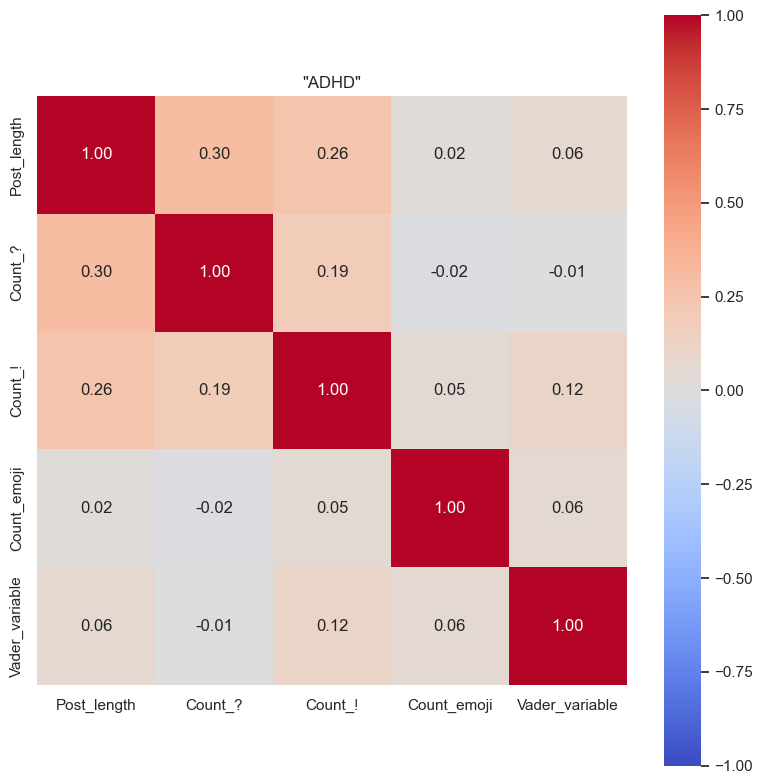

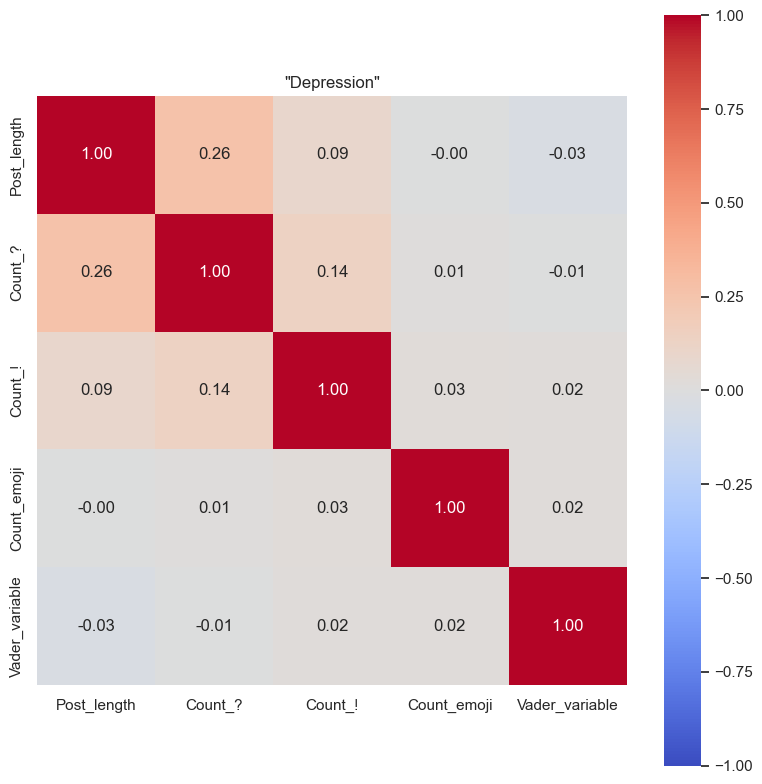

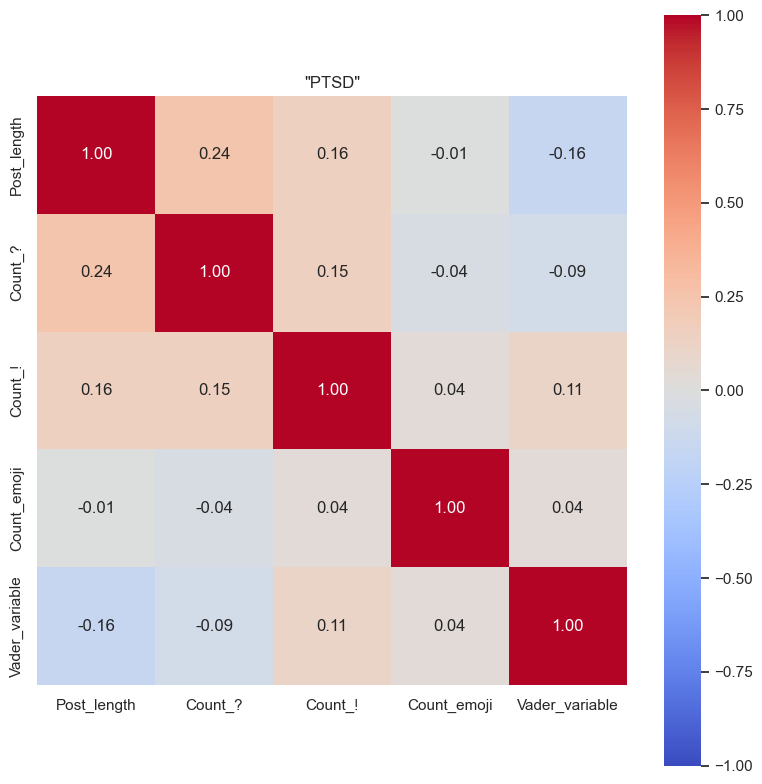

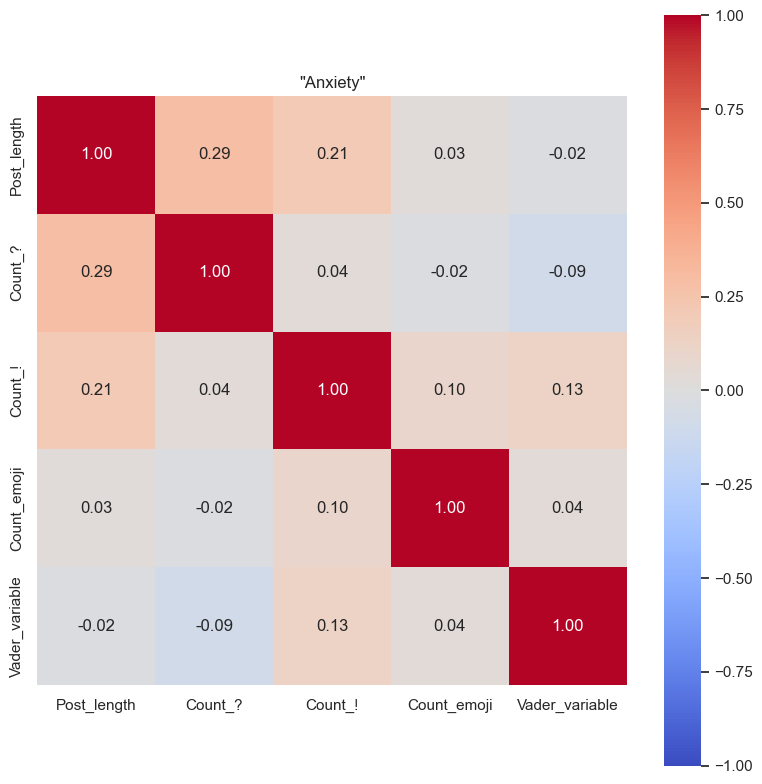

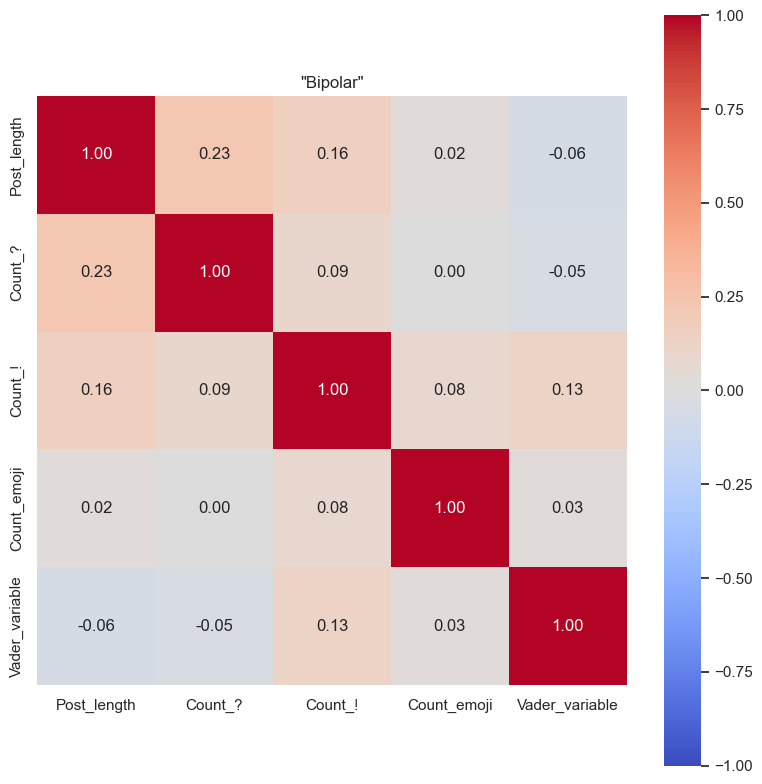

In [ ]:
for label in unique_labels:
    subset_df = cleaned_df[cleaned_df['label'] == label]
    
    # Calculate the correlation matrix for each lable
    numeric_cols = ['Post_length','Count_?','Count_!','Count_emoji','Vader_variable']
    corr_matrix = subset_df[numeric_cols].corr()
    
    plt.figure(figsize=(8, 8))
    
    # Heatmap
    sb.heatmap(
        corr_matrix, 
        annot=True,          
        cmap='coolwarm',     # Blue for negative, red for positive
        vmin=-1, vmax=1,     # create scale from -1 to 1
        square=True, 
        fmt='.2f',           # Round to 2 decimal places
        annot_kws={"size": 12}
    )
    
    plt.title(f'"{label}"')
    plt.tight_layout()
    plt.show()

## HEAT MAP ANALYSIS
as we compare length use of Punctuation and TEST scores we can realise following point:

- As users write longer posts, they naturally ask more questions. They aren't just writing diary entries; they are actively seeking advice, clarity, or reassurance from the community.
- For ADHD (0.26) and Anxiety (0.21), the correlation is distinctly positive. When these users write long posts, they are highly animated, using lots of exclamation points to express excitement, urgency, or panic, While Depression (0.09) and Personality Disorder (0.05). These numbers are basically zero. This is a brilliant clinical insight: when severely depressed users write massive 2,000-word essays, they almost entirely stop using exclamation points. The text becomes a flat, exhausted stream of words.
- The count for emojis doesnt truly demonstrate any form of connection or influence of disorder in user texts so its not found useful
- Even with punctuation added, a post with 50 exclamation points isn't mathematically guaranteed to be highly positive or highly negative.
